<a href="https://colab.research.google.com/github/Krishna62186/Loan-Approval-Prediction/blob/main/ML_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Load Dataset

In [ ]:
df = pd.read_csv("loan_data.csv")
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


#Basic Structure

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [ ]:
df.shape

(45000, 14)

In [ ]:
df.columns.to_list()

['person_age',
 'person_gender',
 'person_education',
 'person_income',
 'person_emp_exp',
 'person_home_ownership',
 'loan_amnt',
 'loan_intent',
 'loan_int_rate',
 'loan_percent_income',
 'cb_person_cred_hist_length',
 'credit_score',
 'previous_loan_defaults_on_file',
 'loan_status']

In [ ]:
df.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


In [ ]:
df.isnull().sum()

,0
person_age,0
person_gender,0
person_education,0
person_income,0
person_emp_exp,0
person_home_ownership,0
loan_amnt,0
loan_intent,0
loan_int_rate,0
loan_percent_income,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.dtypes

,0
person_age,float64
person_gender,object
person_education,object
person_income,float64
person_emp_exp,int64
person_home_ownership,object
loan_amnt,float64
loan_intent,object
loan_int_rate,float64
loan_percent_income,float64


#Categorical Value Counts

In [ ]:
df["person_gender"].value_counts()

,count
person_gender,
male,24841
female,20159


In [ ]:
df["person_education"].value_counts().to_frame()

,count
person_education,
Bachelor,13399
Associate,12028
High School,11972
Master,6980
Doctorate,621


In [ ]:
df["person_home_ownership"].value_counts().to_frame()

,count
person_home_ownership,
RENT,23443
MORTGAGE,18489
OWN,2951
OTHER,117


In [ ]:
df["loan_intent"].value_counts().to_frame()

,count
loan_intent,
EDUCATION,9153
MEDICAL,8548
VENTURE,7819
PERSONAL,7552
DEBTCONSOLIDATION,7145
HOMEIMPROVEMENT,4783


#Target Variable Distribution

loan_status
0    35000
1    10000
Name: count, dtype: int64
loan_status
0    0.777778
1    0.222222
Name: proportion, dtype: float64


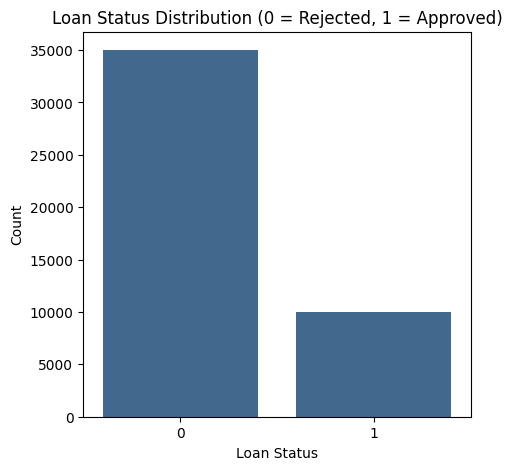

In [ ]:
print(df['loan_status'].value_counts())
print(df['loan_status'].value_counts(normalize=True))

plt.figure(figsize=(5,5))
sns.countplot(x=df['loan_status'], color="#34699A")
plt.title("Loan Status Distribution (0 = Rejected, 1 = Approved)")
plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.show()

#Correlation Heatmap

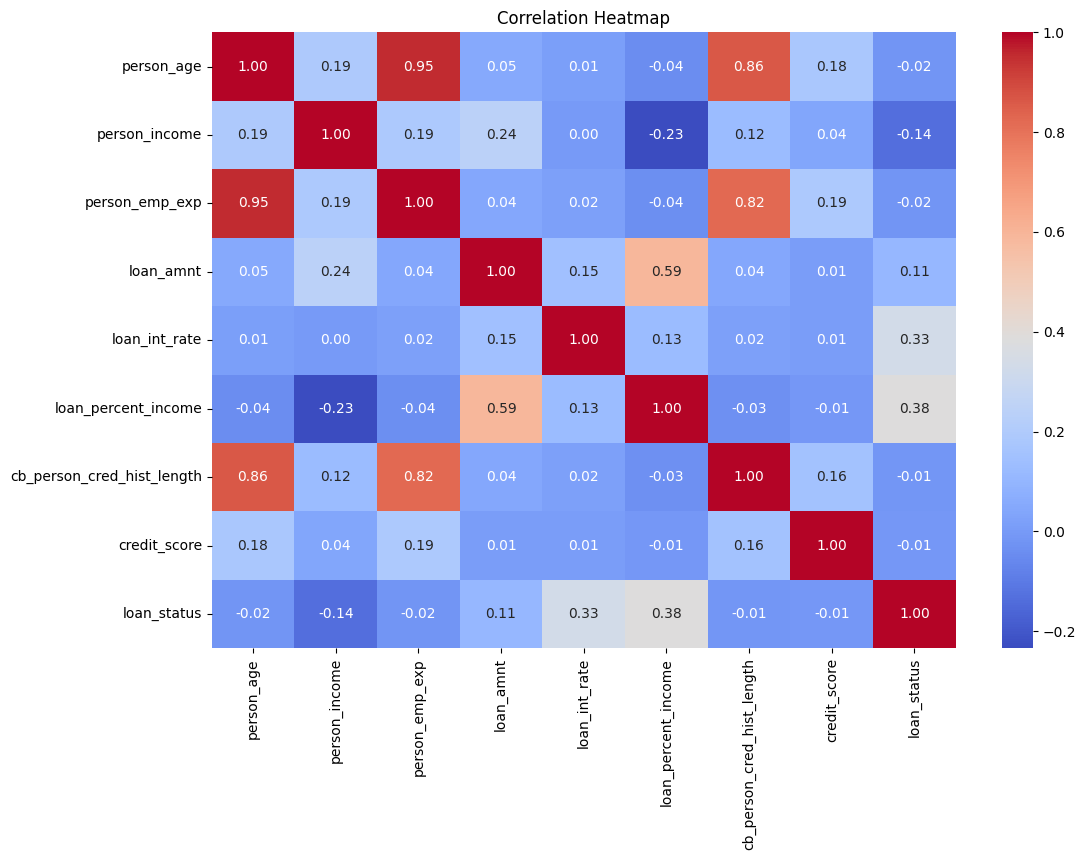

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title("Correlation Heatmap")
plt.show()

#Groupby Analysis


In [ ]:
df.groupby("person_education")["person_income"].agg(["max","mean","min","count"])

,max,mean,min,count
person_education,,,,
Associate,7200766.0,80641.623628,8000.0,12028
Bachelor,5545545.0,79703.319725,8000.0,13399
Doctorate,1440982.0,87234.541063,9824.0,621
High School,5556399.0,80224.597645,8000.0,11972
Master,1080918.0,80491.924355,8000.0,6980


In [ ]:
df.groupby("person_education")["loan_intent"].value_counts().to_frame()

count
person_education loan_intent             
Associate        EDUCATION           2434
                 MEDICAL             2241
                 VENTURE             2052
                 PERSONAL            2024
                 DEBTCONSOLIDATION   1901
                 HOMEIMPROVEMENT     1376
Bachelor         EDUCATION           2705
                 MEDICAL             2520
                 VENTURE             2341
                 PERSONAL            2277
                 DEBTCONSOLIDATION   2200
                 HOMEIMPROVEMENT     1356
Doctorate        MEDICAL              134
                 PERSONAL             109
                 VENTURE              107
                 EDUCATION             95
                 DEBTCONSOLIDATION     93
                 HOMEIMPROVEMENT       83
High School      EDUCATION           2550
                 MEDICAL             2275
                 VENTURE             2092
                 PERSONAL            2003
                 DEBTCONSOLIDATION   1856
                 HOMEIMPROVEMENT     1196
Master           MEDICAL             1378
                 EDUCATION           1369
                 VENTURE             1227
                 PERSONAL            1139
                 DEBTCONSOLIDATION   1095
                 HOMEIMPROVEMENT      772

In [ ]:
df.groupby("person_home_ownership")["person_income"].agg(["count"])

,count
person_home_ownership,
MORTGAGE,18489
OTHER,117
OWN,2951
RENT,23443


#Outlier Detection (Boxplots)


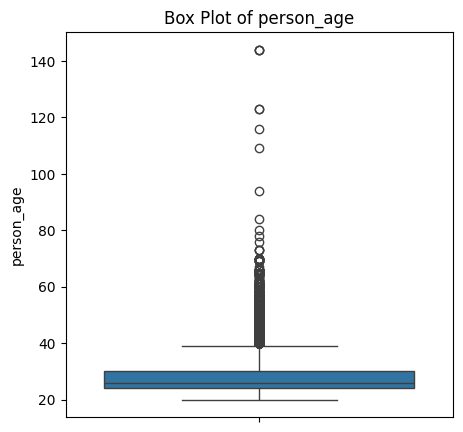

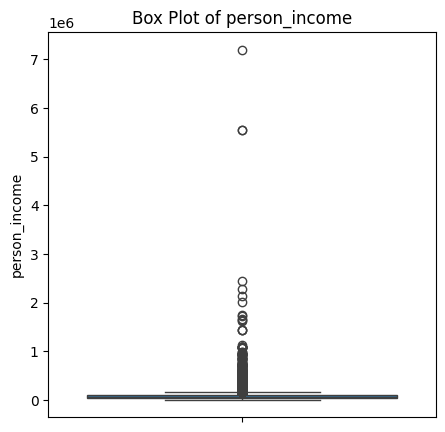

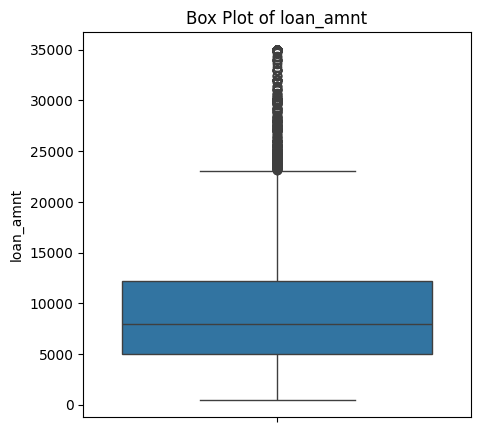

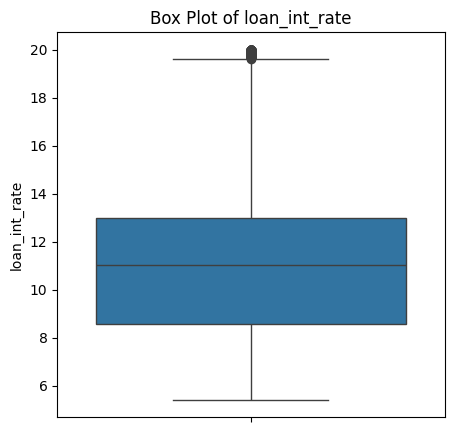

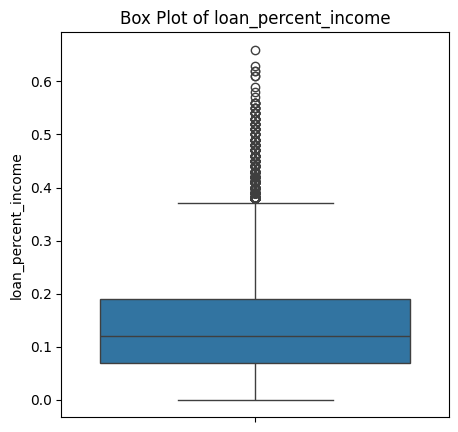

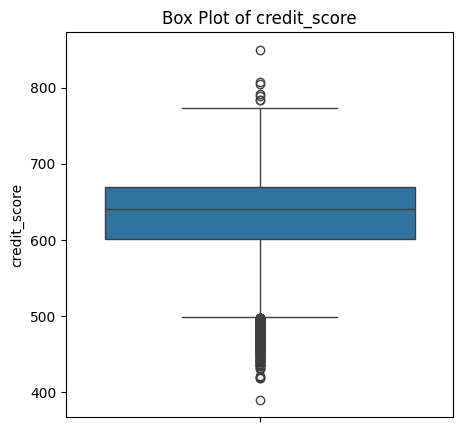

In [ ]:
columns = ["person_age","person_income","loan_amnt","loan_int_rate","loan_percent_income","credit_score"]

for col in columns:
    plt.figure(figsize=(5,5))
    sns.boxplot(y=df[col])
    plt.title(f"Box Plot of {col}")
    plt.ylabel(col)
    plt.show()

#Categorical Distributions

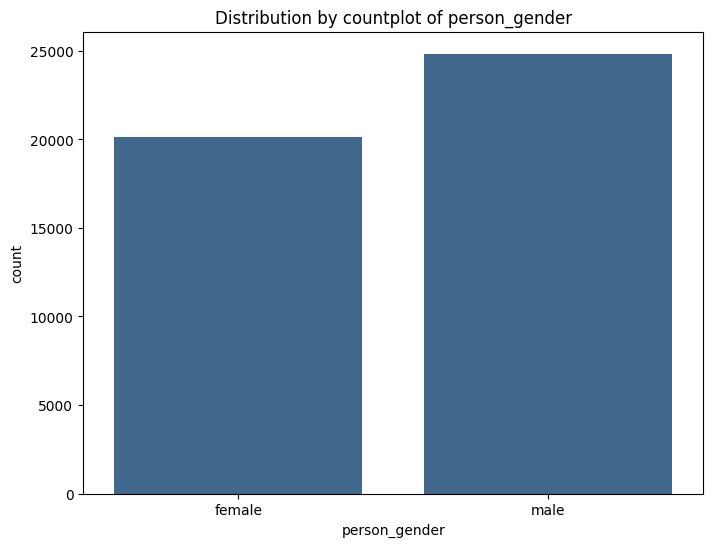

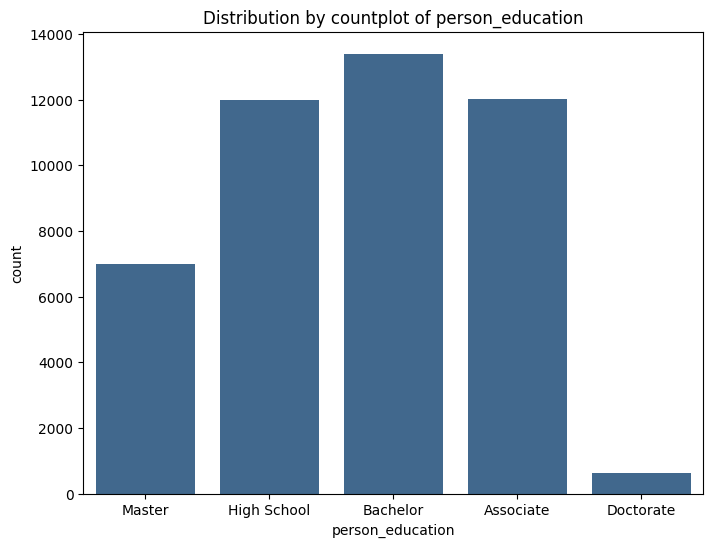

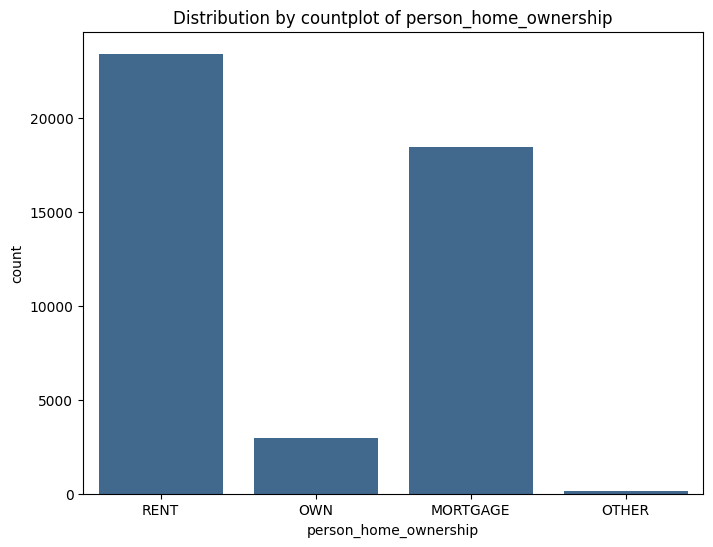

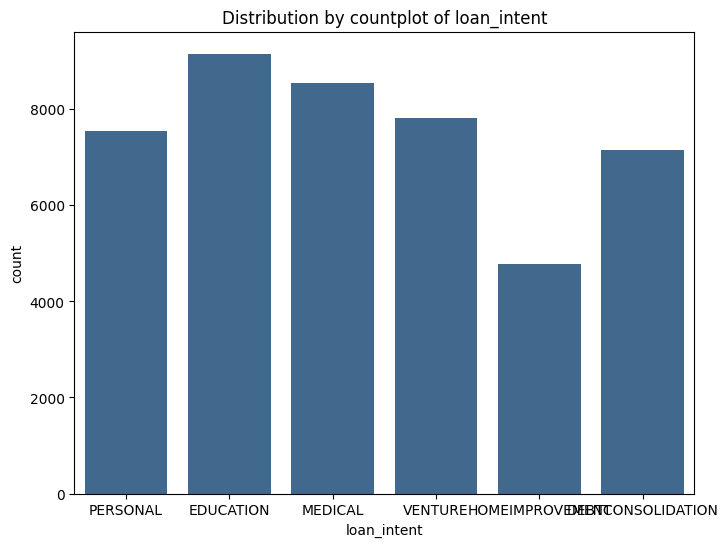

In [ ]:
cols = ["person_gender","person_education","person_home_ownership","loan_intent"]

for col in cols:
    plt.figure(figsize=(8,6))
    sns.countplot(x=df[col], color="#34699A")
    plt.title(f"Distribution by countplot of {col}")
    plt.ylabel("count")
    plt.show()

#Bivariate Analysis: Features vs Target (new)

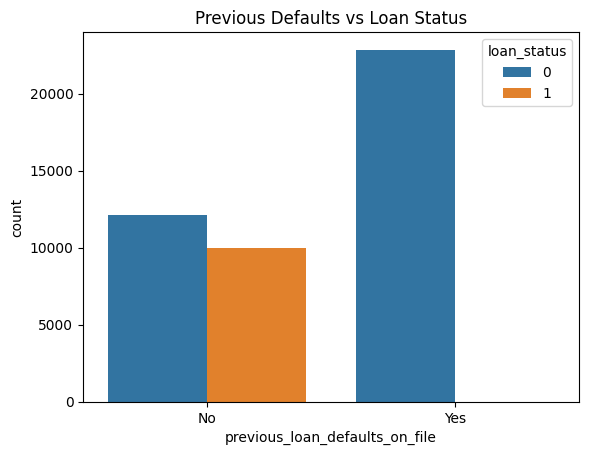

In [ ]:
sns.countplot(x='previous_loan_defaults_on_file', hue='loan_status', data=df)
plt.title("Previous Defaults vs Loan Status")
plt.show()

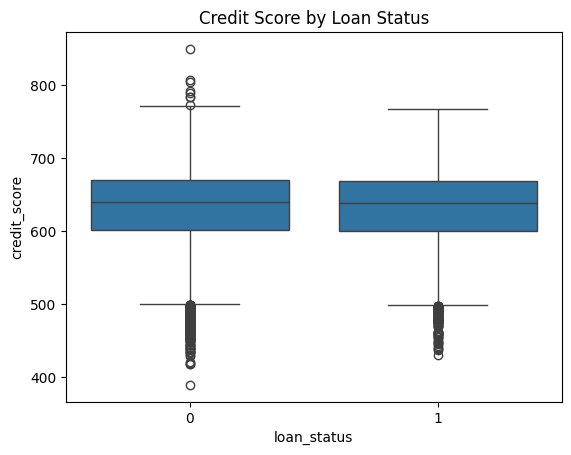

In [ ]:
sns.boxplot(x='loan_status', y='credit_score', data=df)
plt.title("Credit Score by Loan Status")
plt.show()

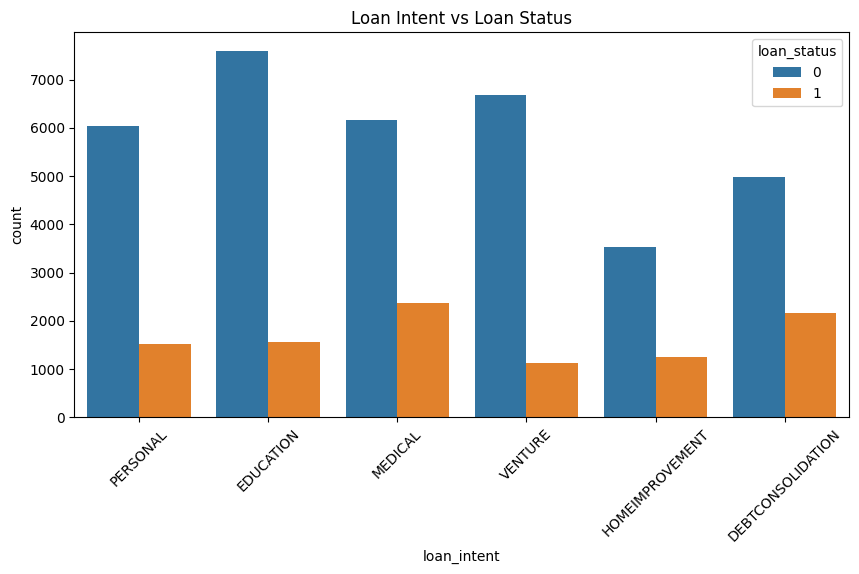

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(x='loan_intent', hue='loan_status', data=df)
plt.xticks(rotation=45)
plt.title("Loan Intent vs Loan Status")
plt.show()

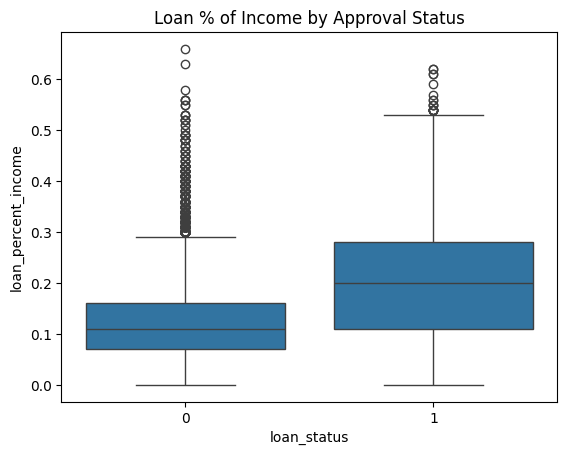

In [ ]:
sns.boxplot(x='loan_status', y='loan_percent_income', data=df)
plt.title("Loan % of Income by Approval Status")
plt.show()

#Data Cleaning (consolidated, single clean block)

In [ ]:
# Check missing values and duplicates
print(df.isnull().sum())
print("Duplicates:", df.duplicated().sum())
df = df.drop_duplicates()

# Sanity-check numeric ranges
print(df[['person_age','person_income','person_emp_exp','credit_score']].describe())

# Remove unrealistic values
df = df[df['person_age'] <= 100]                              # remove impossible ages
df = df[df['person_emp_exp'] <= (df['person_age'] - 14)]      # exp can't exceed working years
df = df.reset_index(drop=True)

print("Final shape after cleaning:", df.shape)

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64
Duplicates: 0
         person_age  person_income  person_emp_exp  credit_score
count  45000.000000   4.500000e+04    45000.000000  45000.000000
mean      27.764178   8.031905e+04        5.410333    632.608756
std        6.045108   8.042250e+04        6.063532     50.435865
min       20.000000   8.000000e+03        0.000000    390.000000
25%       24.000000   4.720400e+04        1.000000    601.000000
50%       26.000000   6.704800e+04        4.000000    640.000000
75%       30.0